# 4 - Autoencoder utilizando o dataset Fashion-MNIST
Equipe:
*   Andre Lopes
*   Elias
*   Igor

**Link do github**: https://github.com/torres-elias/deep-learning-ufpb

**Dataset**: https://www.kaggle.com/datasets/zalando-research/fashionmnist/data



In [ ]:
#Importação de bibliotecas comumente usadas durante o código
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


In [ ]:
import os

arquivo = os.path.join(path, "fashion-mnist_train.csv")
data = pd.read_csv(arquivo)

data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


## Verificando Outliers

In [ ]:
# Pixels apenas (sem label)
pixels = data.iloc[:, 1:]

# Média de pixel por imagem
mean_per_image = pixels.mean(axis=1)

# Desvio padrão por imagem
std_per_image = pixels.std(axis=1)

# Identificar imagens com média incomum (> 3 desvios padrões da média geral)
mean_threshold_high = mean_per_image.mean() + 3*mean_per_image.std()
mean_threshold_low = mean_per_image.mean() - 3*mean_per_image.std()

outliers_mean = data[(mean_per_image > mean_threshold_high) | (mean_per_image < mean_threshold_low)]

print(f"Número de outliers por média de pixel: {len(outliers_mean)}")

Número de outliers por média de pixel: 37


/tmp/ipykernel_982/1434859881.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = row[0]


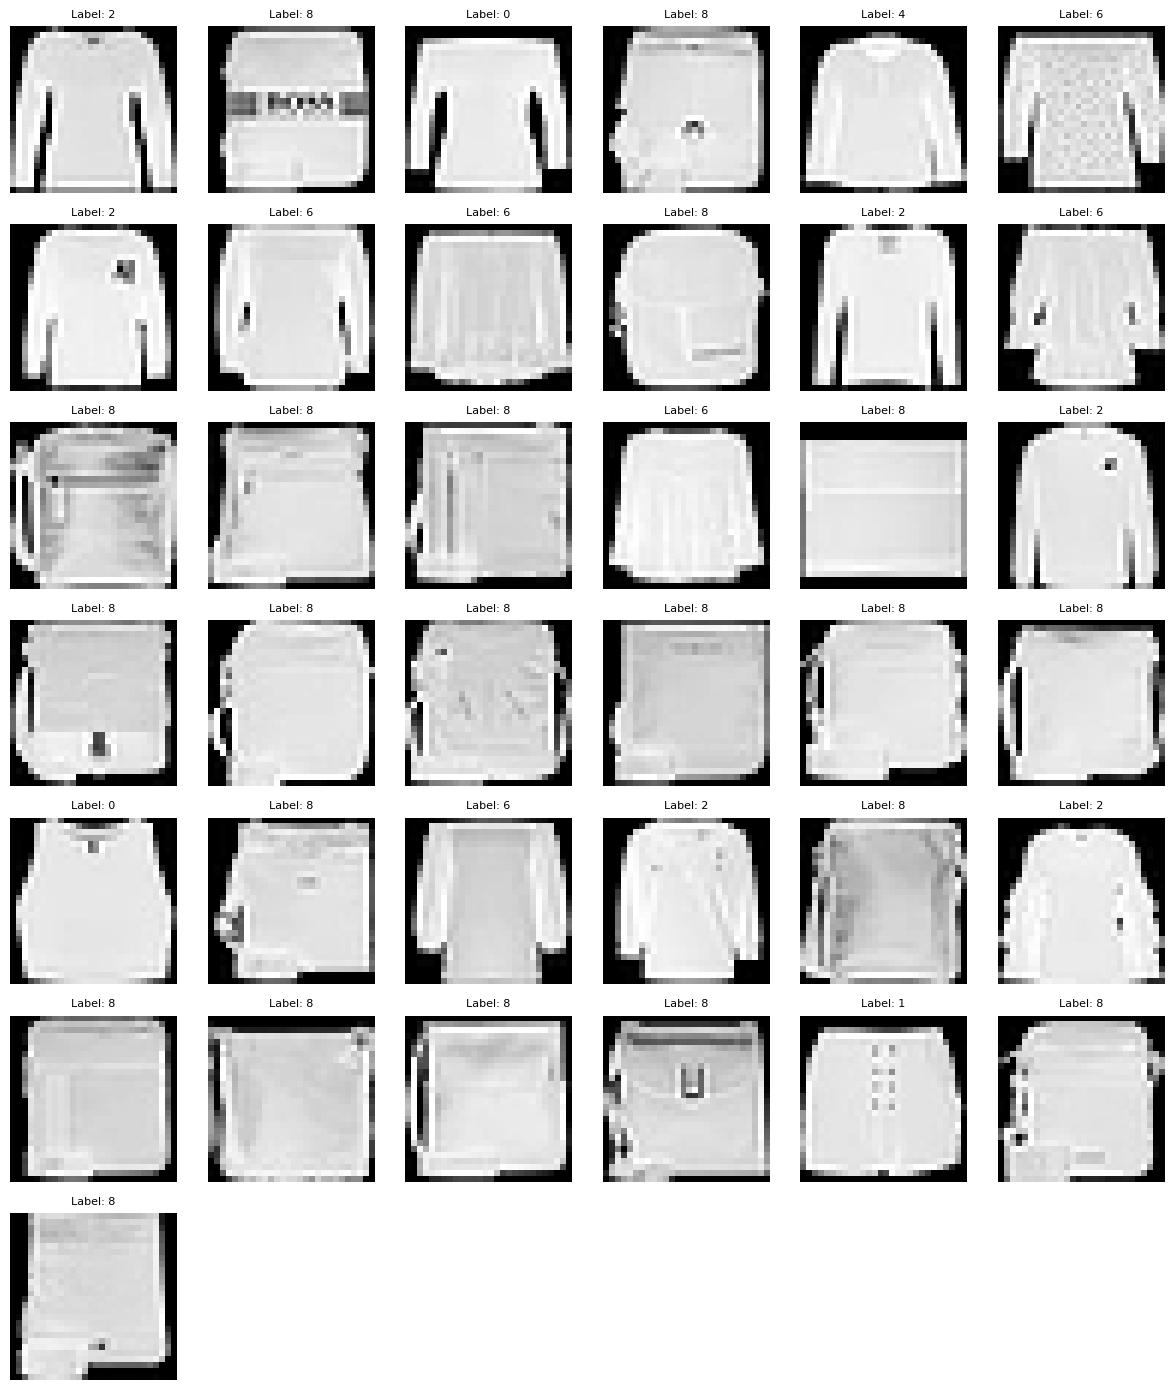

In [ ]:
import matplotlib.pyplot as plt
import math

# Número de outliers
num_outliers = len(outliers_mean)

# Definir tamanho da grade
cols = 6
rows = math.ceil(num_outliers / cols)

#Plotando as imagens dos outliers
plt.figure(figsize=(cols*2, rows*2))

for i, (_, row) in enumerate(outliers_mean.iterrows()):
    image = row[1:].values.reshape(28, 28)
    label = row[0]

    plt.subplot(rows, cols, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Testando imagens (opcional)

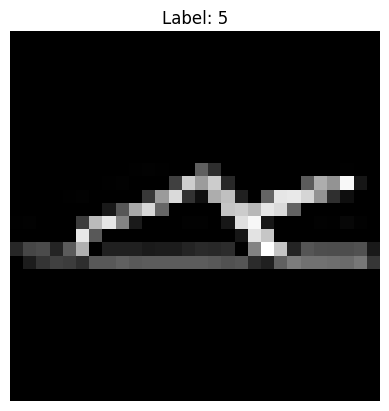

In [ ]:
# Escolher uma imagem específica
index = 7

# Label da imagem
label = data.iloc[index, 0]

# Pixels da imagem
pixels = data.iloc[index, 1:].values

# Remontar matriz 28x28
image = pixels.reshape(28, 28)

# Mostrar imagem
plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

# Pré-processamento de dados

## Verificando dados duplicados

In [ ]:
data.shape

(60000, 785)

In [ ]:
#Conta quantas ocorrências de duplicatas exatas nos dados
duplicadas = data[data.duplicated()]

duplicadas.shape

(43, 785)

In [ ]:
# Remove duplicatas exatas (linha inteira)
data = data.drop_duplicates()

data.shape

(59957, 785)

## Dividindo x e y

In [ ]:
#Puxando dataset de teste
arquivo = os.path.join(path, "fashion-mnist_test.csv")
data_test = pd.read_csv(arquivo)

data_test.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Definir o nome da sua coluna alvo
target_column = 'label'

# 2. Separar as features (X) e o alvo (y)

# y recebe APENAS a coluna alvo.
y_train = data[target_column]
y_test = data_test[target_column]
# X recebe todas as colunas, EXCETO a coluna alvo.
X_train = data.drop(columns=[target_column])
X_test = data_test.drop(columns=[target_column])


# 4. Verificar as dimensões dos conjuntos resultantes
print("Dimensões das features de treino (X_train):", X_train.shape)
print("Dimensões dos rótulos de treino (y_train):", y_train.shape)
print("---")
print("Dimensões das features de teste (X_test):", X_test.shape)
print("Dimensões dos rótulos de teste (y_test):", y_test.shape)

Dimensões das features de treino (X_train): (59957, 784)
Dimensões dos rótulos de treino (y_train): (59957,)
---
Dimensões das features de teste (X_test): (10000, 784)
Dimensões dos rótulos de teste (y_test): (10000,)


## Verificando se existem valores nulos

In [ ]:
nulos = X_train.isnull().sum()
print(nulos)

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 784, dtype: int64


##Normalização por min-maxing scaling

In [ ]:
#Normalização por min-maxing scaling
X_train = (X_train.values.astype(np.float32)) / np.float32(255.0)
X_test = (X_test.values.astype(np.float32)) / np.float32(255.0)

#Aplicando AutoEncoder

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from tensorflow.keras.models import Model

# Reshape para (num_samples, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


# Encoder
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2DTranspose(32, (3,3), strides=2, activation='relu', padding='same')(encoded)
x = Conv2DTranspose(64, (3,3), strides=2, activation='relu', padding='same')(x)
decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Autoencoder
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Treino
autoencoder.summary()
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_split=0.1
)

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_24             │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_25             │ (None, 28, 28, 64)     │        18,496 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,425 (185.25 KB)

 Trainable params: 47,425 (185.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.1310 - val_loss: 0.0086
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0085 - val_loss: 0.0085
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0085 - val_loss: 0.0084
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0083 - val_loss: 0.0083
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0082 - val_loss: 0.0082
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0082 - val_loss: 0.0082
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0082 - val_loss: 0.0082
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0081 - val_loss: 0.0081
Epoch 9/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0081 - val_loss: 0.0081
Epoch 10/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0080 - val_loss: 0.0080
Epoch 11/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0080 - val_loss: 0.0080
Epoch 12/50
422/422 ━━━━━━━━━━━━━━━━━━━━

#Avaliando AutoEncoder

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='Erro treino')
plt.plot(history.history['val_loss'], label='Erro validação')
plt.xlabel('Epoch')
plt.ylabel('Erro médio (loss)')
plt.title('Curva de erro durante o treinamento')
plt.legend()
plt.show()

In [ ]:
import numpy as np

# Reconstruir imagens do conjunto de teste
decoded_imgs = autoencoder.predict(X_test)

# Calcular erro de reconstrução para cada imagem
mse_per_image = np.mean(np.square(X_test - decoded_imgs), axis=(1,2,3))

# Erro médio geral
mse_total = np.mean(mse_per_image)
print("Erro médio de reconstrução (MSE):", mse_total)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Erro médio de reconstrução (MSE): 4.34295e-07


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


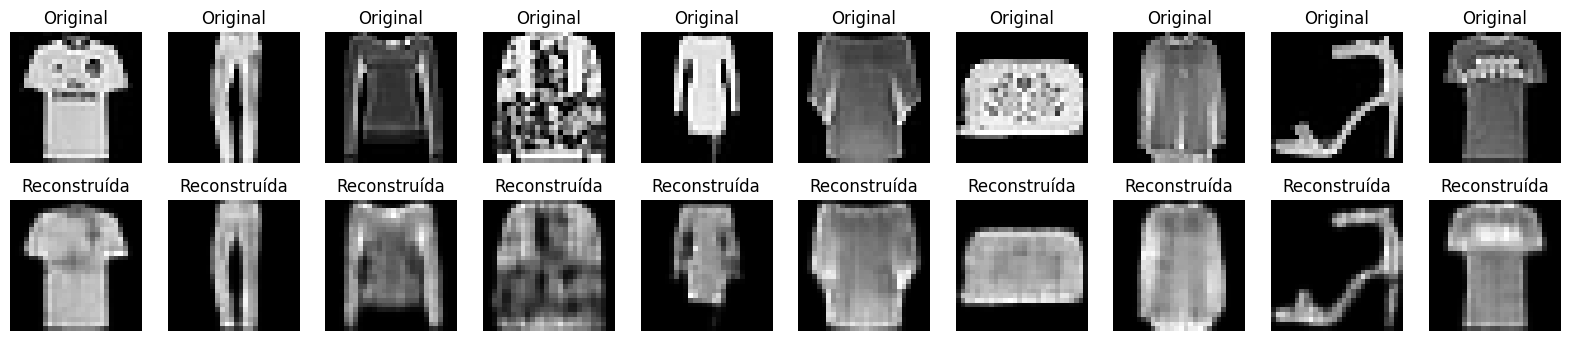

In [ ]:
import matplotlib.pyplot as plt

# Reconstruir algumas imagens do teste
decoded_imgs = autoencoder.predict(X_test[:10])

n = 10
plt.figure(figsize=(20,4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstruída
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstruída")
    plt.axis('off')
plt.show()

#Adicionando Ruido Gaussiano Aditivo na imagem

In [ ]:
import numpy as np

def add_noise(X, noise_factor=0.0003, mean=0.0):
    noise = np.random.normal(mean, noise_factor, X.shape)
    X_ruido = X + noise
    return np.clip(X_ruido, 0., 1.)

noise_factor = 0.0003
X_train_ruido = add_noise(X_train, noise_factor)
X_test_ruido = add_noise(X_test, noise_factor)

##Visualizando o ruido adicionado

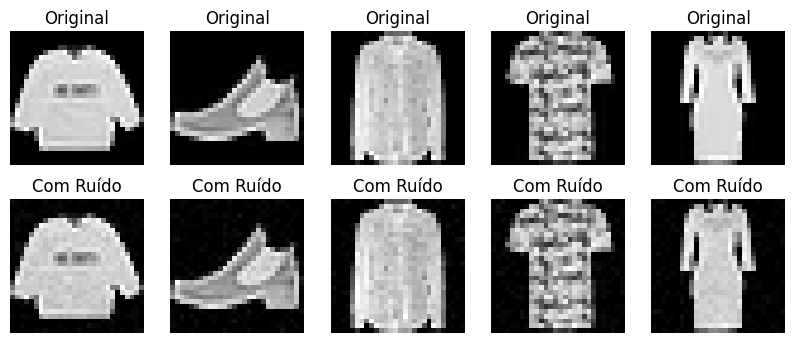

In [ ]:
import matplotlib.pyplot as plt

n = 5
plt.figure(figsize=(10,4))

for i in range(n):

    # original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # com ruído
    ax = plt.subplot(2, n, i+n+1)
    plt.imshow(X_train_ruido[i].reshape(28,28), cmap='gray')
    plt.title("Com Ruído")
    plt.axis("off")

plt.show()

# Autoencoder com ruido

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from tensorflow.keras.models import Model

# Reshape para (num_samples, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


# Encoder
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2DTranspose(32, (3,3), strides=2, activation='relu', padding='same')(encoded)
x = Conv2DTranspose(64, (3,3), strides=2, activation='relu', padding='same')(x)
decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Autoencoder
denoising_autoencoder = Model(input_img, decoded)
denoising_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Treino
denoising_autoencoder.summary()
history = denoising_autoencoder.fit(
    X_train_ruido, X_train,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_split=0.1
)

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_32             │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_33             │ (None, 28, 28, 64)     │        18,496 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,425 (185.25 KB)

 Trainable params: 47,425 (185.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.1395 - val_loss: 0.0086
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0086 - val_loss: 0.0086
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0085 - val_loss: 0.0085
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0084 - val_loss: 0.0083
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0082 - val_loss: 0.0082
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0082 - val_loss: 0.0082
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0081 - val_loss: 0.0081
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0080 - val_loss: 0.0080
Epoch 9/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0080 - val_loss: 0.0080
Epoch 10/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0079 - val_loss: 0.0080
Epoch 11/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0079 - val_loss: 0.0080
Epoch 12/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 

#Avaliando Denoising Autoencoder

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='Erro treino')
plt.plot(history.history['val_loss'], label='Erro validação')
plt.xlabel('Epoch')
plt.ylabel('Erro médio (loss)')
plt.title('Curva de erro durante o treinamento')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


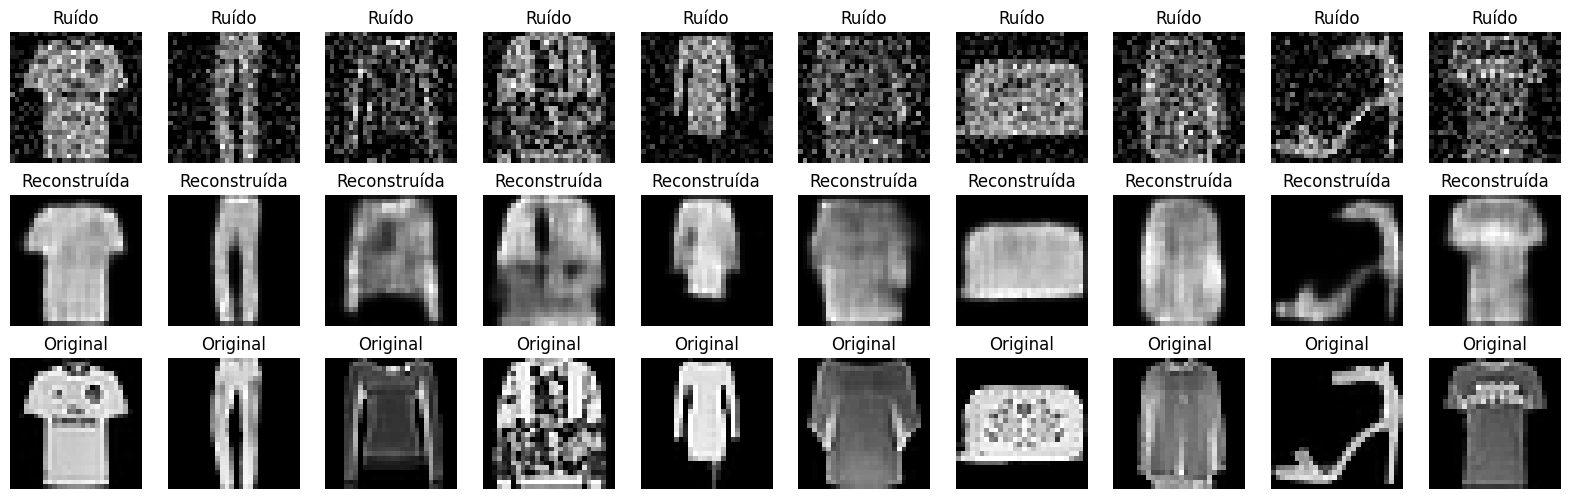

In [ ]:
decoded_imgs = autoencoder.predict(X_test_ruido)

n = 10
plt.figure(figsize=(20,6))

for i in range(n):

    # noisy
    ax = plt.subplot(3, n, i+1)
    plt.imshow(X_test_ruido[i].reshape(28,28), cmap='gray')
    plt.title("Ruído")
    plt.axis("off")

    # Recriado
    ax = plt.subplot(3, n, i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstruída")
    plt.axis("off")

    # original
    ax = plt.subplot(3, n, i+2*n+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

plt.show()